In [ ]:
!pip install git+https://github.com/KrishnaswamyLab/omics_toolbox.git --no-deps

# Introduction

In this tutorial, we demonstrate how to use PHATE (Potential of Heat-diffusion for Affinity-based Transition Embedding) to analyze a cancer plasticity dataset of HCC38 breast cancer cells undergoing epigenetic reprogramming via TSA (Trichostatin A) treatment across five conditions.

We review the following steps:

[1. Loading 10X data](#loading)  
[2. Preprocessing: Filtering, Normalizing, and Transforming](#preprocessing)  
[3. Embedding Data Using PHATE](#embedding)  

## 0. Installation

Run the cell above to install `omics_toolbox`, which bundles all required dependencies (`phate`, `scanpy`, etc.).

## 1. Import libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import scanpy as sc
import phate

# 2. Loading 10x Data

### Downloading Data from Google Drive

The cancer plasticity dataset contains HCC38 breast cancer cells treated with TSA (Trichostatin A), a histone deacetylase inhibitor that induces epigenetic reprogramming and cancer cell plasticity. It includes five conditions:

| Folder | Label |
|---|---|
| `HCC38_2D_culture` | Day 0 (untreated) |
| `TSA-48HR_3` | Day 2 |
| `TSA-D12` | Day 12 |
| `TSA-D18` | Day 18 |
| `TSA-D30` | Day 30 |

Each folder contains three files: `barcodes.tsv.gz`, `features.tsv.gz`, and `matrix.mtx.gz`. For more information about how CellRanger produces these files, check out the [Gene-Barcode Matrices Documentation](https://support.10xgenomics.com/single-cell-gene-expression/software/pipelines/latest/output/matrices).

Here's the directory structure:
```
download_path
└── cancer_plasticity
    ├── HCC38_2D_culture
    │   ├── barcodes.tsv.gz
    │   ├── features.tsv.gz
    │   └── matrix.mtx.gz
    ├── TSA-48HR_3
    │   ├── barcodes.tsv.gz
    │   ├── features.tsv.gz
    │   └── matrix.mtx.gz
    ├── TSA-D12
    ├── TSA-D18
    └── TSA-D30
```

In [3]:
import omics_toolbox as ot

data_path = ot.download_cancer_plasticity(download_path='../../data/raw/cancer_plasticity')

Retrieving folder contents


Retrieving folder 1VUcIZ37OsgJJ1FtFPNrltZRXfo4L0Rct HCC38_2D_culture
Processing file 1MfiFBuVkoYiOJtq5hwdUiZAUkkEub5SZ barcodes.tsv.gz
Processing file 1I5GklGdjUq_g3K99lRQVXzKen63tPkbX features.tsv.gz
Processing file 13ocELyUcr0v9Cpx2WYr0gNtTv0bZpx1c matrix.mtx.gz
Retrieving folder 1FKP-5LXsjBEcirzXci6GkOPddfj1oEK8 TSA-48HR_3
Processing file 1lVG-q8MPEEKlq1HRKbhPot3RHUTiHXXn barcodes.tsv.gz
Processing file 1xmfY_zV-jy3M2g1lJamgvxKbf19MCllb features.tsv.gz
Processing file 1rGUw5swviKsDWMMprN1boIRZYf3w1Kxp matrix.mtx.gz
Retrieving folder 1hedUYfH5tC9EgFiEVtPig1Bw2rXo3D4z TSA-D12
Processing file 1owdjS3wmKJ89LjoHaiE-sV2xRVZWm_bH barcodes.tsv.gz
Processing file 1LF9l8pGubYbR4ByJ4Z9tRgrHvmKkY00D features.tsv.gz
Processing file 11LgwQeEnm_U19h1wFxGq3sEMXLxG-4Tr matrix.mtx.gz
Retrieving folder 1YZ8xv5MQI4S36j39ty8mQp8OI77v7GlX TSA-D18
Processing file 1BaKPOvuaJBrAR8WvXvHt0qak7XE_tQrW barcodes.tsv.gz
Processing file 1WP4gdRnMAhh_VpqDmvn-C8DBaJD_Bfo5 features.tsv.gz
Processing file 1Xdobp-W7Afn

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1MfiFBuVkoYiOJtq5hwdUiZAUkkEub5SZ
To: /Users/joaofelipe/Yale/github_projects/omics_toolbox/data/raw/cancer_plasticity/HCC38_2D_culture/barcodes.tsv.gz
100%|██████████| 18.5k/18.5k [00:00<00:00, 15.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1I5GklGdjUq_g3K99lRQVXzKen63tPkbX
To: /Users/joaofelipe/Yale/github_projects/omics_toolbox/data/raw/cancer_plasticity/HCC38_2D_culture/features.tsv.gz
100%|██████████| 305k/305k [00:00<00:00, 5.12MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13ocELyUcr0v9Cpx2WYr0gNtTv0bZpx1c
From (redirected): https://drive.google.com/uc?id=13ocELyUcr0v9Cpx2WYr0gNtTv0bZpx1c&confirm=t&uuid=3a6d75e4-764d-4cff-9788-90205a59f9e4
To: /Users/joaofelipe/Yale/github_projects/omics_toolbox/data/raw/cancer_plasticity/HCC38_2D_culture/matrix.mtx.gz
100%|██████████| 35.9M/35.9M [00:01<0


Done! Cancer plasticity data is in: ../../data/raw/cancer_plasticity



Download completed


Scanpy's `read_10x_mtx` reads the standard 10X CellRanger output format:
- `matrix.mtx.gz` (expression matrix)
- `features.tsv.gz` (gene names)
- `barcodes.tsv.gz` (cell barcodes)

In [4]:
# If data is already downloaded, set data_path manually:
# data_path = '../../data/raw/cancer_plasticity'

samples = ['HCC38_2D_culture', 'TSA-48HR_3', 'TSA-D12', 'TSA-D18', 'TSA-D30']
labels  = ['Day 0', 'Day 2', 'Day 12', 'Day 18', 'Day 30']

adatas = []
for sample, label in zip(samples, labels):
    adata = sc.read_10x_mtx(
        os.path.join(data_path, sample),
        var_names='gene_symbols',
        make_unique=True,
        cache=True,
    )
    adata.obs['condition'] = label
    adatas.append(adata)

# Concatenate all samples
adata = sc.concat(adatas, merge='same')
adata.obs_names_make_unique()
print(f"Loaded {adata.n_obs} cells and {adata.n_vars} genes")

Loaded 22186 cells and 33538 genes


/Users/joaofelipe/Yale/github_projects/omics_toolbox/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3. Filtering

### 3.1. Quality control metrics
Quality Control from scanpy's [documentation](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html):

_The scanpy function calculate_qc_metrics() calculates common quality control (QC) metrics, which are largely based on calculateQCMetrics from scater [McCarthy et al., 2017]. One can pass specific gene population to calculate_qc_metrics() in order to calculate proportions of counts for these populations._

In [5]:
# Calculate QC metrics
## Here we are also computing quality control specific for Mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

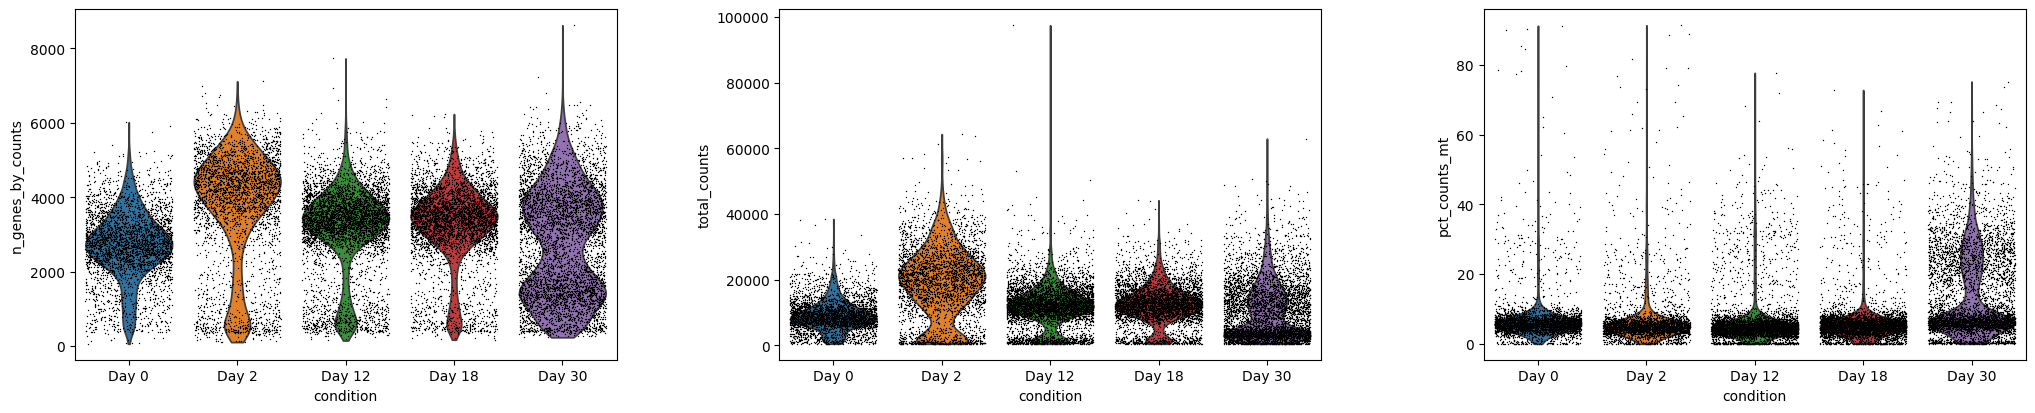

In [6]:
# Visualize QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='condition')

### 3.2 Library Size Filtering
We filter out cells that have either very large or very small library sizes. For this data set, library size correlates somewhat with sample and so we filter on a per-sample basis.

In this case, we eliminate the top and bottom 10% of cells for each sample. Similar results are obtained with simpler, less conservative filtering.

First, let's plot to observe the distribution.

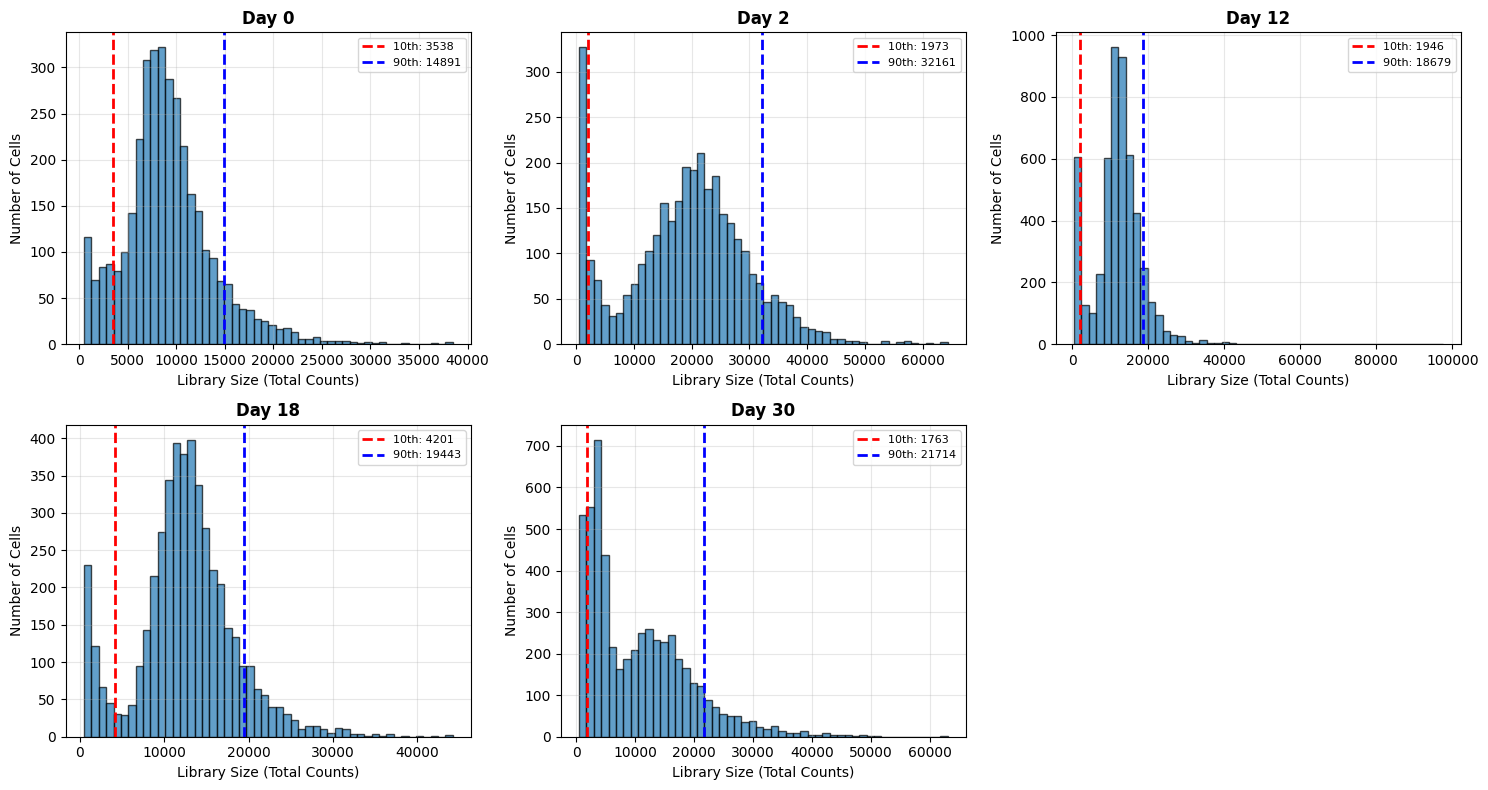

In [7]:
# Let's set a percentile to filter
min_percentile = 10  # Filter cells lower than the 10th percentile
max_percentile = 90  # Filter cells higher than the 90th percentile

# Create a plot for each sample
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (sample, label) in enumerate(zip(samples, labels)):
    # Filter data for this sample
    sample_mask = adata.obs['condition'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    # Calculate thresholds for this sample
    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    # Plot
    axes[idx].hist(sample_counts, bins=50, alpha=0.7, edgecolor='black')
    axes[idx].axvline(threshold_min, color='red', linestyle='--', linewidth=2,
                      label=f'{min_percentile}th: {threshold_min:.0f}')
    axes[idx].axvline(threshold_max, color='blue', linestyle='--', linewidth=2,
                      label=f'{max_percentile}th: {threshold_max:.0f}')
    axes[idx].set_xlabel('Library Size (Total Counts)', fontsize=10)
    axes[idx].set_ylabel('Number of Cells', fontsize=10)
    axes[idx].set_title(f'{label}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

# Hide the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Filter cells per sample based on library size percentiles
cells_to_keep = []

for sample, label in zip(samples, labels):
    # Get cells for this sample
    sample_mask = adata.obs['condition'] == label
    sample_counts = adata.obs.loc[sample_mask, 'total_counts']

    # Calculate thresholds for this sample
    threshold_min = np.percentile(sample_counts, min_percentile)
    threshold_max = np.percentile(sample_counts, max_percentile)

    # Identify cells to keep for this sample
    keep_mask = (sample_counts >= threshold_min) & (sample_counts <= threshold_max)
    cells_to_keep.extend(sample_counts[keep_mask].index.tolist())

    print(f"{label}: keeping {keep_mask.sum()}/{len(sample_counts)} cells "
          f"(range: {threshold_min:.0f} - {threshold_max:.0f})")

# Filter the AnnData object
adata = adata[cells_to_keep, :].copy()
print(f"\nTotal cells after filtering: {adata.n_obs}")

Day 0: keeping 2833/3543 cells (range: 3538 - 14891)
Day 2: keeping 2712/3392 cells (range: 1973 - 32161)
Day 12: keeping 4171/5214 cells (range: 1946 - 18679)
Day 18: keeping 3735/4669 cells (range: 4201 - 19443)
Day 30: keeping 4294/5368 cells (range: 1763 - 21714)

Total cells after filtering: 17745


### 3.3 Removing rare genes
Let's eliminate genes that are expressed in 10 cells or fewer.

In [9]:
# Eliminate genes that are expressed in few cells
min_cells = 10
sc.pp.filter_genes(adata, min_cells=min_cells)

### 3.4. Normalization
To correct for differences in library sizes, we divide each cell by its library size and then rescale by the median library size.

In [10]:
# Normalize to median library size
sc.pp.normalize_total(adata, target_sum=np.median(adata.obs['total_counts']))

### 3.5. Dead cell removal
Dead cells are likely to have a higher mitochondrial RNA expression level than live cells. Therefore, we remove suspected dead cells by eliminating cells that have the highest mitochondrial RNA expression levels on average.  

First let's look at the distribution of mitochondrial genes.

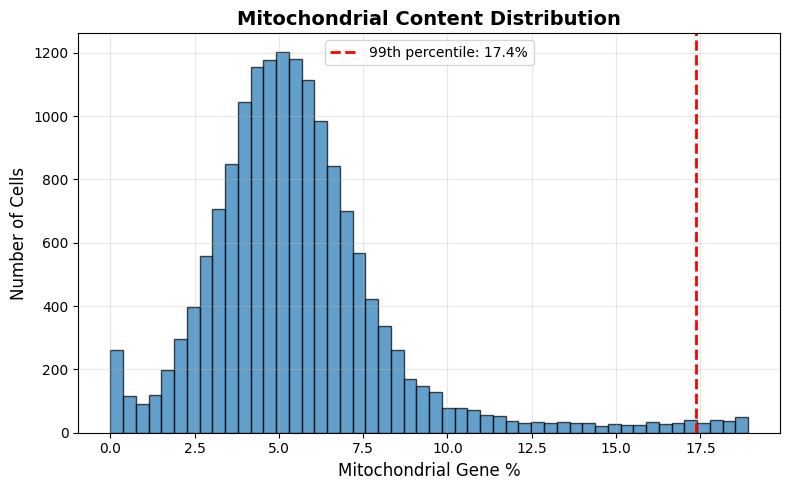

In [13]:
# Get mitochondrial percentages
mito_pct = adata.obs['pct_counts_mt']
mito_percentile = 99
mito_threshold = np.percentile(mito_pct, mito_percentile)  # Upper percentile

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mito_pct, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(mito_threshold, color='red', linestyle='--', linewidth=2,
           label=f'{mito_percentile}th percentile: {mito_threshold:.1f}%')
ax.set_xlabel('Mitochondrial Gene %', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title('Mitochondrial Content Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Filter cells with high mitochondrial content
adata = adata[adata.obs['pct_counts_mt'] < mito_threshold].copy()

### 3.6. Transformation

In scRNA-seq analysis, the data is often $\log$-transformed. This typically requires the addition of some small value to avoid taking $\log(0)$. We avoid this issue entirely by instead taking the square root transform. The square root function has a similar form as the $\log$ function with the added benefit of being stable at 0.

In [15]:
# Square root transform (alternative to log transform, stable at zero)
# sc.pp.log1p(adata)  # You can also use log1p if preferred
adata.X = np.sqrt(adata.X)

## 4. Embedding Data Using PHATE

### 4.1 Instantiating the PHATE estimator

The API of PHATE models that of Scikit Learn. First, you instantiate a PHATE estimator object with the parameters for fitting the PHATE embedding to a given dataset. Next, you use the `fit` and `fit_transform` functions to generate an embedding. For more information, check out [**the PHATE readthedocs page**](http://phate.readthedocs.io/).

We'll just use the default parameters for now, but the following parameters can be tuned (read our documentation at [phate.readthedocs.io](https://phate.readthedocs.io/) to learn more):

* `knn` : Number of nearest neighbors (default: 5). Increase this (e.g. to 20) if your PHATE embedding appears very disconnected. You should also consider increasing `knn` if your dataset is extremely large (e.g. >100k cells)
* `decay` : Alpha decay (default: 15). Decreasing `decay` increases connectivity on the graph, increasing `decay` decreases connectivity. This rarely needs to be tuned. Set it to `None` for a k-nearest neighbors kernel.
* `t` : Number of times to power the operator (default: 'auto'). This is equivalent to the amount of smoothing done to the data. It is chosen automatically by default, but you can increase it if your embedding lacks structure, or decrease it if the structure looks too compact.
* `gamma` : Informational distance constant (default: 1). `gamma=1` gives the PHATE log potential, but other informational distances can be interesting. If most of the points seem concentrated in one section of the plot, you can try `gamma=0`.

In [16]:
# Run PHATE
phate_operator = phate.PHATE(knn=5, decay=15, n_jobs=-2, verbose=True)
adata.obsm['X_phate'] = phate_operator.fit_transform(adata.X)

Calculating PHATE...
  Running PHATE on 15810 observations and 19366 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 12.06 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.25 seconds.
    Calculating affinities...
    Calculated affinities in 1.15 seconds.
  Calculated graph and diffusion operator in 13.50 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.95 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.32 seconds.
  Calculated landmark operator in 4.27 seconds.
  Calculating optimal t...
    Automatically selected t = 23
  Calculated optimal t in 0.89 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.66 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 2.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.30 seconds.
Calculate

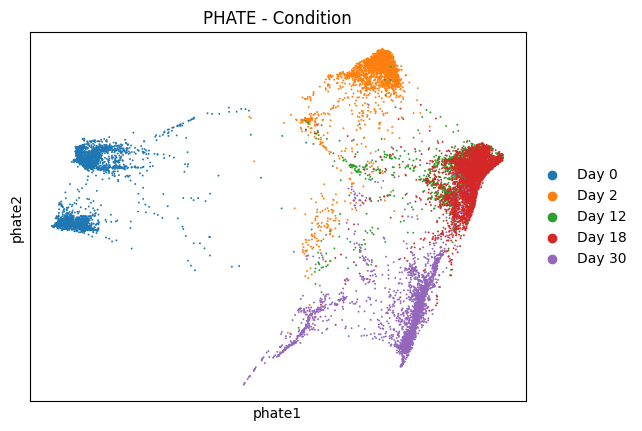

In [17]:
# Visualize PHATE colored by condition
sc.pl.embedding(adata, basis='phate', color='condition', cmap='Spectral', title='PHATE - Condition')

Since we are looking for subtle structure and we expect some of the trajectories to be sparse, we might want to decrease `knn` from the default of 5, and reduce `t` from the automatic value. For single-cell RNA-seq you can try `knn` as low as 3 or 4 if you're looking for subtle structure, or as high as 30 or 40 if you have hundreds of thousands of cells. We'll also reduce `alpha` here to 15 to partially offset the decreased connectivity as a result of decreasing `knn`.

In [18]:
phate_operator.set_params(knn=4, decay=15, t=12)
# We could also create a new operator:
# phate_operator = phate.PHATE(knn=4, decay=15, t=12, n_jobs=-2)

adata.obsm['X_phate'] = phate_operator.fit_transform(adata.X)

Calculating PHATE...
  Running PHATE on 15810 observations and 19366 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 11.19 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.17 seconds.
    Calculating affinities...
    Calculated affinities in 0.52 seconds.
  Calculated graph and diffusion operator in 11.92 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.98 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.73 seconds.
  Calculated landmark operator in 4.73 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.39 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.35 seconds.
Calculated PHATE in 18.86 seconds.


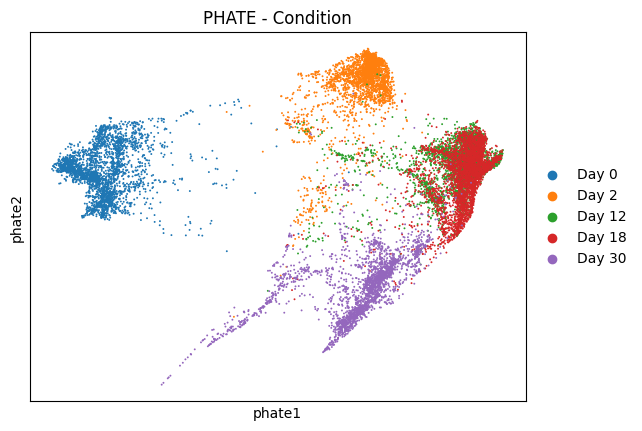

In [19]:
# Visualize PHATE colored by condition
sc.pl.embedding(adata, basis='phate', color='condition', cmap='Spectral', title='PHATE - Condition')

We can also visualize the embedding in 3D. (using matplotlib)

Calculating metric MDS...
  SGD-MDS may not have converged: stress changed by -1.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Calculated metric MDS in 1.58 seconds.


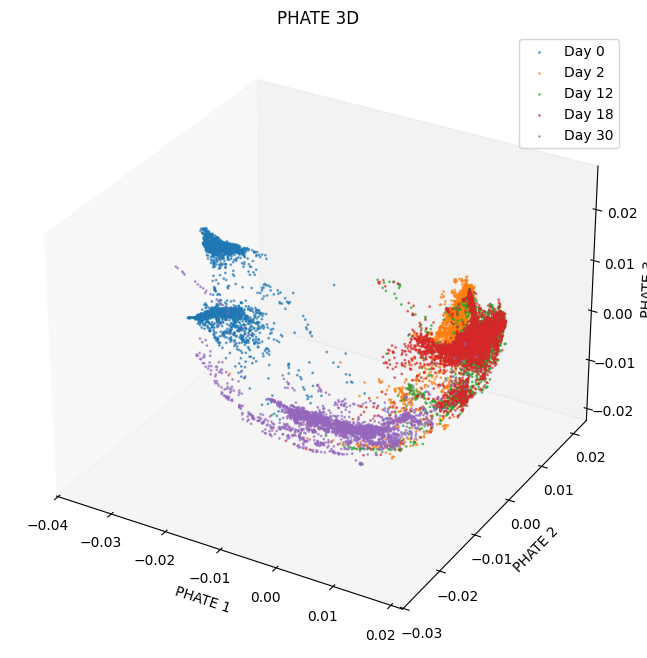

In [20]:
# 3D PHATE
phate_operator.set_params(n_components=3)
adata.obsm['X_phate_3d'] = phate_operator.transform()

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cond in adata.obs['condition'].unique():
    mask = adata.obs['condition'] == cond
    ax.scatter(adata.obsm['X_phate_3d'][mask, 0],
               adata.obsm['X_phate_3d'][mask, 1],
               adata.obsm['X_phate_3d'][mask, 2],
               label=cond, alpha=0.6, s=1)

ax.legend()
ax.grid(False)
ax.set_xlabel('PHATE 1')
ax.set_ylabel('PHATE 2')
ax.set_zlabel('PHATE 3')
plt.title('PHATE 3D')
plt.show()

## 5. Visualize gene expression on PHATE

We can visualize expression of known EMT (Epithelial-to-Mesenchymal Transition) markers on the PHATE embedding to understand the biological meaning of the trajectories:

- **ZEB1** and **TWIST1**: EMT transcription factors, upregulated in mesenchymal cells
- **VIM** (Vimentin): mesenchymal marker
- **CDH1** (E-cadherin): epithelial marker, downregulated during EMT
- **CDH2** (N-cadherin): mesenchymal marker, upregulated during EMT
- **EPCAM**: epithelial cell adhesion molecule

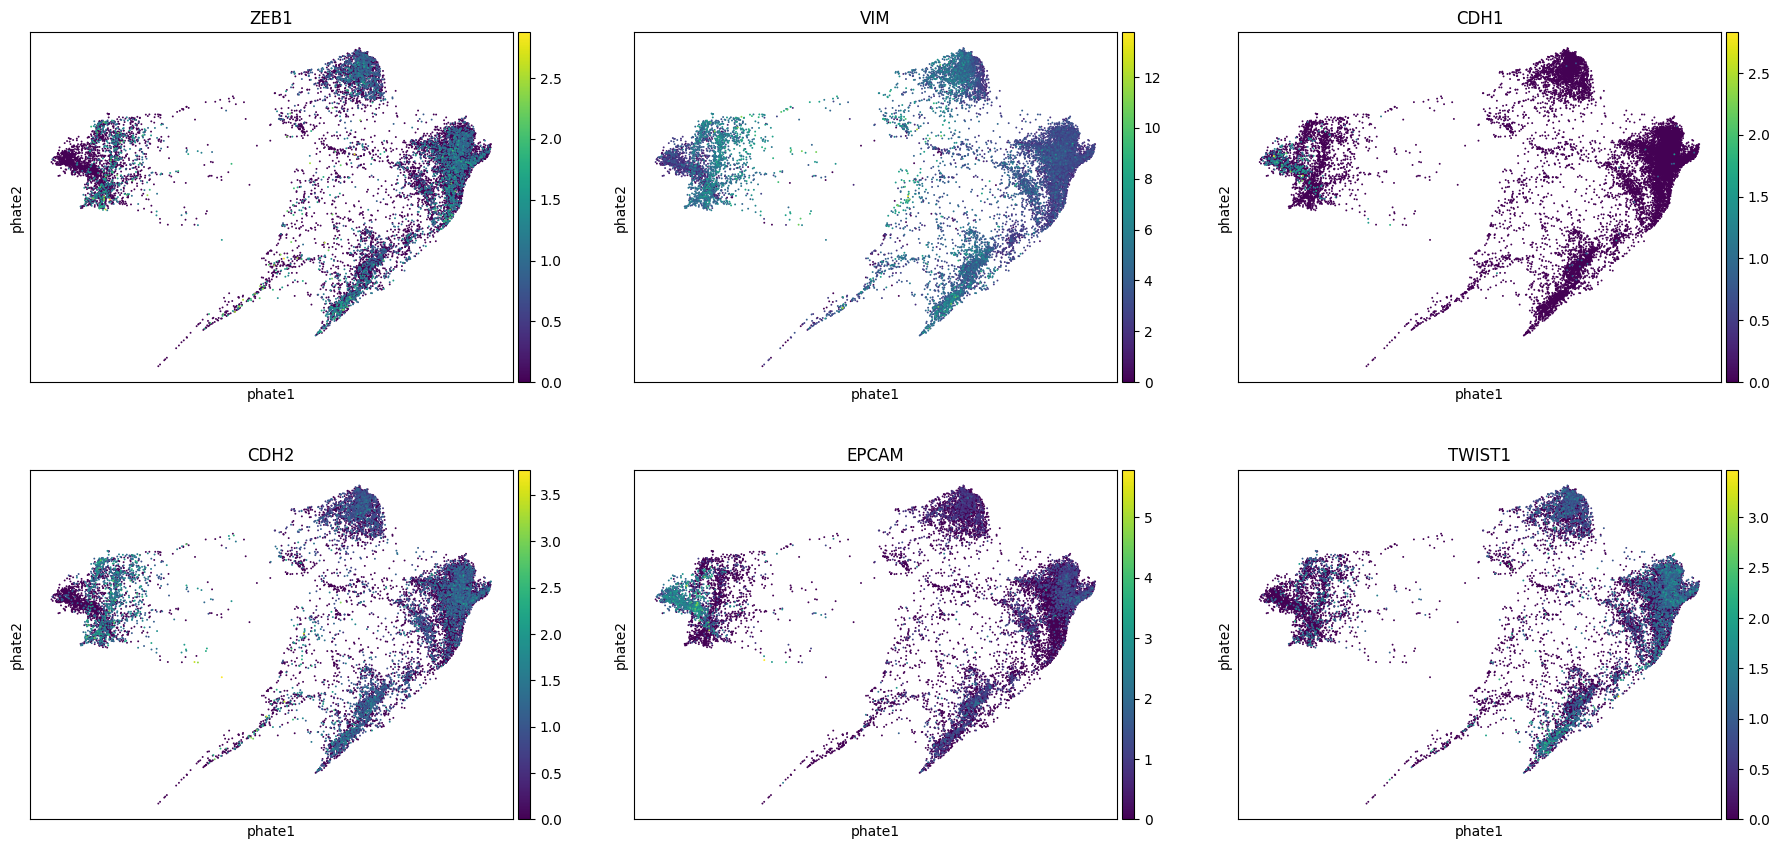

In [21]:
# Visualize EMT marker genes
genes = ['ZEB1', 'VIM', 'CDH1', 'CDH2', 'EPCAM', 'TWIST1']
sc.pl.embedding(adata, basis='phate', color=genes, cmap='viridis', ncols=3)

## Comparison with other visualization tools

In this section we will compare PHATE to other common visualization tools on this dataset.

* PCA
* t-SNE

Neither of these methods accept sparse input, so this will only work if you have a lot of memory available. Also, we apply PCA before t-SNE, as is common practice.

In [22]:
import time

# PCA
start = time.time()
sc.tl.pca(adata, n_comps=50)  # Computes PCA and stores in adata.obsm['X_pca']
end = time.time()
print("Embedded PCA in {:.2f} seconds.".format(end - start))

# t-SNE (typically done after PCA for speed)
start = time.time()
sc.tl.tsne(adata, n_pcs=50)  # Uses PCA results, stores in adata.obsm['X_tsne']
end = time.time()
print("Embedded t-SNE in {:.2f} seconds.".format(end - start))

Embedded PCA in 10.03 seconds.
Embedded t-SNE in 22.46 seconds.


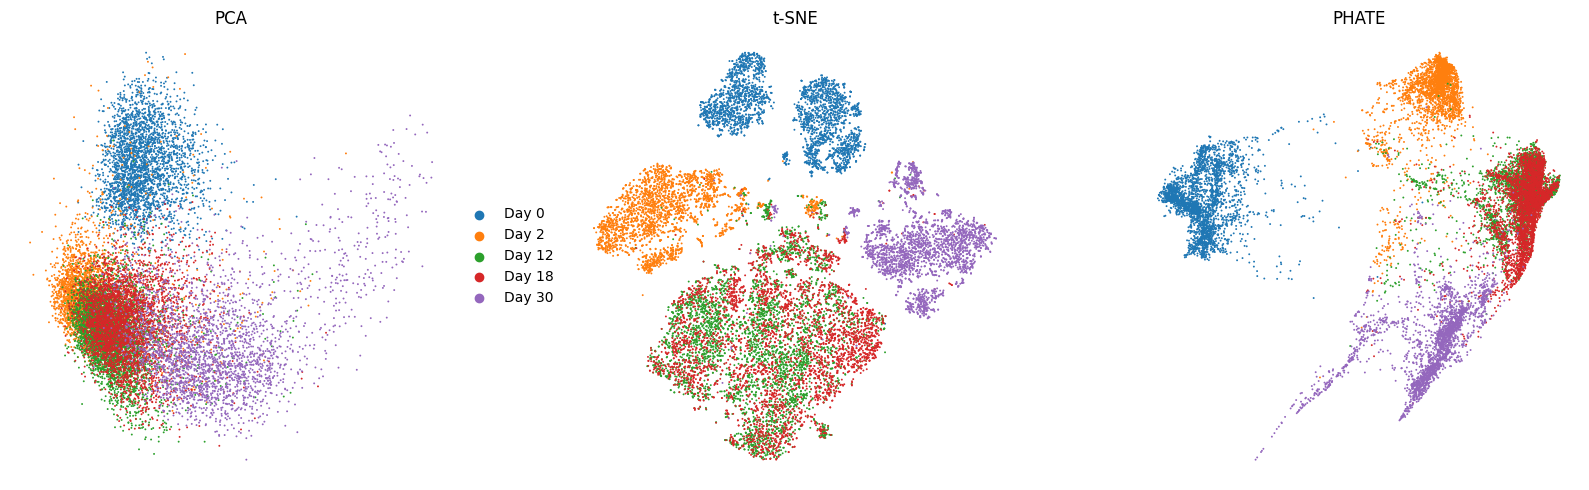

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# plotting PCA
sc.pl.embedding(adata, basis='pca', color='condition',
                title='PCA', show=False, ax=ax1,
                frameon=False, colorbar_loc=None)

# plotting t-SNE
sc.pl.embedding(adata, basis='tsne', color='condition',
                title='t-SNE', show=False, ax=ax2, legend_loc='none',
                frameon=False, colorbar_loc=None)

# plotting PHATE
sc.pl.embedding(adata, basis='phate', color='condition',
                title='PHATE', show=False, ax=ax3, legend_loc='none',
                frameon=False, colorbar_loc=None)

plt.tight_layout()
plt.show()